### 6/23/26 just checking to see if the output is normal

## Background

The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

Note that a general equation for the diascalar material transformation for a process $P$ for a water mass $\mathcal{M}$ defined to be all tracer $\lambda$ values greater than $\tilde \lambda$. The convergence of a flux $\mathcal{F} = \nabla \cdot \mathbf{F}$.

$$
    \mathcal{G}_{\ge}^{\text{(P)}} = \int_{\mathcal{A_R}(\tilde\lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \mathcal{F} \, \text{d}S = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
$$

And the subsequent diascalar material transformation demonstrating a relationship between mixing calculated as a convergence of a diffusive flux and mixing calculated as tracer variance decay is

*tbh, idk if this is the equation they use, but this is the equation I derived in my advancement proposal*
$$
\begin{equation}
\mathcal{G}^{\text{(phy)}} = \underbrace{\int_{\mathcal{A_R}(\tilde \lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \left(- \nabla \cdot \left(-\kappa_{phy} \nabla \lambda\right)\right) \, \text{d}S}_{\text{mixing as conv. of diff. flux}} = \underbrace{-\frac{1}{2} \frac{\partial^2}{\partial \tilde\lambda^2}\left[ \int_{\Omega(\tilde\lambda ,t)} \rho \left( 2 \kappa_{phy} \vert\vert \nabla \lambda \vert\vert^2\right) \, \text{d}V\right]}_{\text{mixing as var. decay}} 
\tag{2}
\end{equation}
$$ 


While Castro et al. describes a relationship between the convergence of a diffusive tracer flux and tracer variance decay for *phyiscal* mixing, we propose to look at *numerical* mixing through a similar framework. This relationship would look very similar to Equation 2, but our we would instead be solving for the term $\mathcal{G}^{\text{(num)}}$ and the diffusivities would be $\kappa_{num}$ rather than $\kappa_{phy}$. 

### Mixing as convergence of a diffusive flux
We quickly run into a problem, which is that $\kappa_{num}$ is unknown when calculating the nuemrical mixing as the convergence of a diffusive flux. Recall that $\kappa_{phy}$ comes from a prescribed background diffusivity. In which case, we need a different way to calculate $\mathcal{G}^{\text{(num)}}$. We propose to do so using the WMT budget residual.

$$
\begin{align}
    \partial_t{\mathcal{M}} &= \Psi + \mathcal{S} + \mathcal{G^{\text{(BF)}}} + \mathcal{G^{\text{(phy)}}} + \mathcal{G^{\text{(num)}}} \\
    \implies \mathcal{G^{\text{(num)}}} & = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}}
    \tag{3}
\end{align} 
$$

### Mixing as tracer variance decay
We *can*, however, calculate a $\kappa_{num}$ when thinking about numerical mixing through the perspective of tracer variance decay, if we use the Discrete Varaince Decay (DVD) algorithm.
Let 
$$
\begin{equation}
	\chi^{\text{(num)}} = \underbrace{\frac{A\{\left(\lambda_i^n\right)^2\} -\left[A\{\lambda_i^n\}\right]^2}{\Delta t}}_{\text{DVD}} = \underbrace{-2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}}_{\substack{\text{discretized mixing}\\\text{as variance decay}}} \approx \underbrace{-2 \kappa_{num}\left(\frac{\partial \lambda}{\partial x}\right)^2}_{\substack{\text{continuous mixing}\\\text{as variance decay}}} \tag{4}
\end{equation}
$$

The $\kappa_{num}$ arises out of the mathematical manipulation of the advection operator to get the rest of thet algorithm.
$$
    \kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x}\right) \tag{5}
$$

The $\chi^{\text{(num)}}$ term is a tendency that can now be written in the WMT framework as 
$$
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
$$

### WMT relationship of numerical mixing as a budget residual and as tracer variance decay.
The following relationship (in terms of the WMT framework) between Equations 2 and 3 then emerges.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi \, \text{d}V\right] \tag{7}
\end{equation}
$$

*do NOT trust the signs in this argument, it depends on the direction you're integrating, and I'm sure I have several sign errors rn*

In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid

### Open files & visualize raw data

In [2]:
# filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
# ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
# ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
# ds_wmt = xr.open_dataset(filepath + 'analysis_members/10km_channel_WMT_Monthly.0001-01-01.nc')
# mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
# descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [95]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

# format ds_dvd so that it includes a time=0 index (otherwise missing first time step)
ds_dvd = xr.concat([ds_dvd.isel(Time=0), ds_dvd],dim='Time')
ds_dvd["xtime"][0]= np.array(b"0001-01-01_00:00:00", dtype="|S64")

ds_dvd['xtime'] = ds_dvd.xtime.assign_attrs(description='time=0 data is copy of time=1')

# interpolate the DVD vertical physical mixing onto nVertLevels
grid_dvd = Grid(ds_dvd, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        periodic = False, 
                        autoparse_metadata=False)
ds_dvd['chiPhyVerTemp_center'] = grid_dvd.interp(ds_dvd.chiPhyVerTemp, 'Z' ,boundary = 'extend')
ds_dvd['chiPhyVerSalt_center'] = grid_dvd.interp(ds_dvd.chiPhyVerSalt, 'Z', boundary = 'extend')

# set time index
time_idx = 115

In [96]:
for i in ds_output.data_vars:
    if 'Mix' in i:
        print(i)

temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency


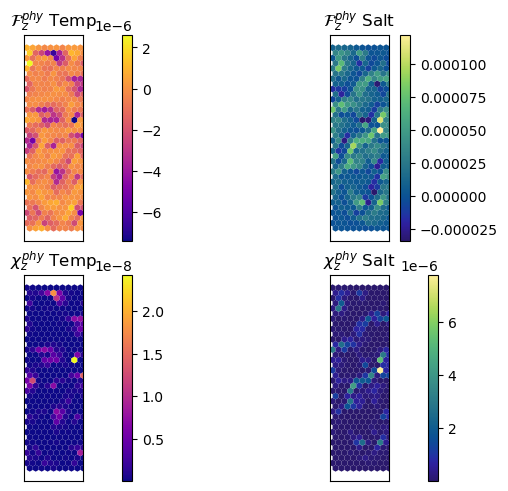

In [115]:
# comparison of mixing
fig,ax = plt.subplots(nrows=2, ncols = 2, constrained_layout=True)

# calculated as convergence of diffusive flux
a = mosaic.polypcolor(ax[0,0],descriptor, ds_output.temperatureVertMixTendency.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
b = mosaic.polypcolor(ax[0,1],descriptor, ds_output.salinityVertMixTendency.isel(Time=time_idx, nVertLevels=0),cmap='cmo.haline')
ax[0,0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[0,1].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')

# calculated as tracer variance decay
c = mosaic.polypcolor(ax[1,0],descriptor, ds_dvd.chiPhyVerTemp_center.isel(Time=time_idx, nVertLevels=0), cmap='plasma')
d = mosaic.polypcolor(ax[1,1],descriptor, ds_dvd.chiPhyVerSalt_center.isel(Time=time_idx, nVertLevels=0), cmap='cmo.haline')
ax[1,0].set_title(r'$\chi_z^{phy}$ Temp')
ax[1,1].set_title(r'$\chi_z^{phy}$ Salt')

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_aspect(1.0)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

fig.colorbar(a, ax = ax[0,0])
fig.colorbar(b, ax = ax[0,1])
fig.colorbar(c, ax = ax[1,0])
fig.colorbar(d, ax = ax[1,1])

## Explanation of data


|Dataset Name|Description|
|--| --|
|`ds_output` | standard output variables (T, S, velo)|
|`ds_dvd` | $\chi^{\text{(phy)}}$ and $\chi^{\text{(num)}}$ from DVD alg.|
|`ds_output` | $\mathcal{F} \,; [^\circ C s^{-1}]$ ; conv. of diff. flux |
|`mesh` | grid variables (cellsOnEdge, etc) |

>- Simulations were run with a linear equation of state such that $\rho_0 = 1027 \, kg/m^3$ $\leftarrow$ CHECK THIS 
>- No prescribed horizontal mixing $\kappa_{phy,x} = 0$, so we expect `TracerHorMixTendency` to be 0 (`ds_output` dataset).
>- Vertical mixing is prescribed using KPP where the background diffusivity is $\kappa_{phy,z} = 10e-5 \, m^2s^{-1}$.
>- The background viscosity is set to $\nu = 10e-4 \, m^2 s^{-1}$.
>- Only wind stress forcing is prescribed.
>- The `TracerSurfaceFluxTendency` in the `ds_output` dataset is 0 because we do not have any boundary forcing that would introduce tracers at the surface.

The $\mathcal{F}$ and $\chi$ outputs require that we calculate $\mathcal{G}^{\text{(phy)}}$ and $\mathcal{G}^{\text{(num)}}$ offline. The following math is necessary.

*Recall that in order to calculate the residual, we need to directly calculate all other terms in the budget*

We need to plug in $\mathcal{F}$ (`TracerVertMixTendency`) into Equation 1.
$$
\begin{equation}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
\end{equation}
$$

We need to plug in $\chi^{\text{(num)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
\end{equation}
$$

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$ from convergence of a diffusive flux

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i} - \tilde\lambda_{i+1}}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*Note that we take are looking at $\lambda_i - \lambda_{i+1}$ rather than the other way around. This is because we defined $\mathcal{M}_\ge$ to account for all salinities **greater** than the threshold lambda $\tilde\lambda$. So we are looking from the saltier value to a fresher value (decreasing $\lambda$), rather than a traditional increase.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class.

## Calculate $\mathcal{G}_\chi^{\text{(phy)}}$ from tracer variance decay

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}_\chi^{\text{(phy)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

### Non-generalized functions for calculating $\mathcal{G}^\text{(phy)}$

In [98]:
# write function to calculate G_F_phy
def calculate_G_F_phy(rho_0, mesh, ds_output, target_coord_spacing = 1):
    # calculate the integrand
    dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
    integrand = (ds_output.salinityVertMixTendency * rho_0 * dV)
    
    # update ds_output dataset to include integrand dataarray
    ds_output['integrand'] = integrand

    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels

    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            periodic = False, 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', boundary = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[1] - target_coords_P1[0]
    
    # transform integrand (currently sitting on center nVertLevels) to salinity_P1 coordinates
    ds_output_salinity_mix_tendencyZ_transformed = grid_nVertLevels.transform(ds_output.integrand, # data we want to transform (on cell centers)
                                                                           'Z', # axis of transformation
                                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                                           method = 'conservative', # method
                                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed.to_dataset(name='integrand_transformed')
    
    # the transform remapped the datavariable to the CENTER of the cell 
    # rename the salinity_P1 coords to salinity
    ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed_ds.rename({'salinity_P1' : 'salinity'})
    
    # add back the salinity_P1 coordinates
    ds_output_salinity_mix_tendencyZ_transformed_ds = ds_output_salinity_mix_tendencyZ_transformed_ds.assign_coords({'salinity_P1' : target_coords_P1})
    
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2

    # then calculate the derivative d_integrand
    # create an array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords_P1) - 2):
        d_tracerMassFlux = ds_output_salinity_mix_tendencyZ_transformed_ds.integrand_transformed[:,:,i] - ds_output_salinity_mix_tendencyZ_transformed_ds.integrand_transformed[:,:,i+1]
        d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # this eliminates the first and last entry in salinity_P1 coords
    salinity_P1_trimmed = target_coords_P1[1:-1]
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    
    # add back salinity_coords
    # after transforming, our datavariable sits on salinity_P1, but we want to maintain salinity as a coordinate
    # interpolate the salinity_P1 values to get salinity values
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    G_F_phy_ds = G_F_phy_ds.assign_coords({'salinity' : salinity_trimmed})

    # remap to get onto matching salinity coordinates
    # make a grid that identifies salinity as the vertical coordinates
    grid_salinity = Grid(G_F_phy_ds, coords={'Z': {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                        periodic = False,
                        autoparse_metadata = False)
    
    G_F_phy_ds['G_F_phy_center'] = grid_salinity.interp(G_F_phy_ds.G_F_phy, 'Z', boundary='extend')

    return G_F_phy_ds

In [99]:
# write function to calculate G_chi_phy
def calculate_G_chi_phy(rho_0, mesh, ds_dvd, target_coord_spacing = 1):
    # calculate the integrand
    dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)
    
    # ds_dvd.chiPhyVerSalt is on nVertLevelsP1, but we need for the datavariable to be on cell centers first
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_dvd, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            periodic = False, 
                            autoparse_metadata=False)
    chi_interp = grid_nVertLevels.interp(ds_dvd.chiPhyVerSalt, axis='Z')
    integrand_chi = rho_0 * chi_interp * dV

    # +2 to ensure that the upper and lower bins have a Gphy = 0
    lower_bound = ds_output.salinity_P1.min() - 2
    upper_bound = ds_output.salinity_P1.max() + 2
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[1] - target_coords_P1[0]
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # we already have our target coordinates set up from calculating G_phy from conv of a diff flux, so we just need to do a conservative transform
    ds_dvd_salinity_chiZ_transformed = grid_nVertLevels.transform(integrand_chi, # currently sitting on cell centers
                                                      'Z',
                                                      target_coords_P1,
                                                      method='conservative',
                                                      target_data = ds_output.salinity_P1)
    
    ds_dvd_salinity_chiZ_transformed_ds = ds_dvd_salinity_chiZ_transformed.to_dataset(name='integrand_chi_transformed')
    
    # the transform remapped the datavariable to the CENTER of the cell 
    # rename the salinity_P1 coords to salinity
    ds_dvd_salinity_chiZ_transformed_ds = ds_dvd_salinity_chiZ_transformed_ds.rename({'salinity_P1' : 'salinity'})

    # calculate the first derivative
    tendency = []
    
    # take the first derivative (from salinty coords to salinity_P1 coords)
    for i in range(0,len(target_coords_P1)-2):
        d_tracerMassFlux = ds_dvd_salinity_chiZ_transformed[:,:,i] - ds_dvd_salinity_chiZ_transformed[:,:,i+1]
        d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
        tendency.append(d_tracerMassFlux_dlambda)
    
    # convert tendency to dataset
    tendency_da = xr.concat(tendency, dim='salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the difference you will lose the first and last entries of the salinity coords
    G_chi_phy = []
    
    for i in range(0,len(target_coords)-2):
        d_tendency = tendency_da[i,:,:] - tendency_da[i+1,:,:]
        dtendency_dlambda = d_tendency / dlambda
        G_chi_phy.append(dtendency_dlambda * -0.5) # by definition, G_phy_chi is multiplied by -1/2
    
    salinity_trimmed = target_coords[1:-1]
    G_chi_phy_ds = (xr.concat(G_chi_phy, dim = 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name = 'G_chi_phy')
    
    # add back the salinity_P1 coordinates
    G_chi_phy_ds = G_chi_phy_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})

    return G_chi_phy_ds

In [100]:
# wrapper function to perform all calculations
def calculate_G_phy(rho_0, mesh,ds_output, ds_dvd):
    G_F_phy_ds = calculate_G_F_phy(rho_0, mesh, ds_output)
    G_chi_phy_ds = calculate_G_chi_phy(rho_0, mesh, ds_dvd)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    G_phy_comp_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_phy_comp_ds

In [101]:
# calculate transformation at every density class
def vertical_cumsum(G_phy_ds, variable, reduce_time_dim_method, time_idx=0):

    if reduce_time_dim_method == 'average':
        G_phy = G_phy_ds[variable].mean(dim='Time').sum(dim='nCells')

    if reduce_time_dim_method == 'isel':
        G_phy = G_phy_ds[variable].isel(Time = time_idx).sum(dim='nCells')
        
    # cumsum from bottom (lowest salinity class) to top (highest salinity class)
    # we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda
    # reduce G_phy_ds along several dimensions
    
    rev_G_phy = np.flipud(G_phy)
    cumsum_rev_G_phy = np.cumsum(rev_G_phy)
    # reverse back to match highest salinity value to lowest cumsum value
    cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

    print('reduced time dimension by ', reduce_time_dim_method)
    if reduce_time_dim_method == 'isel':
        print('time_idx = ', time_idx)

    return G_phy, cumsum_G_phy

-------
--------

In [102]:
G_F_phy_ds, G_chi_phy_ds, G_phy_comp_ds =  calculate_G_phy(1026, mesh,ds_output, ds_dvd)

In [103]:
G_F_phy_avg, cumsum_G_F_phy_avg = vertical_cumsum(G_phy_comp_ds, 'G_F_phy_center', 'average')

reduced time dimension by  average


In [104]:
G_F_phy_isel, cumsum_G_F_phy_isel = vertical_cumsum(G_phy_comp_ds, 'G_F_phy_center', 'isel', time_idx)

reduced time dimension by  isel
time_idx =  115


In [105]:
G_chi_phy_avg, cumsum_G_chi_phy_avg = vertical_cumsum(G_phy_comp_ds, 'G_chi_phy', 'average')

reduced time dimension by  average


In [106]:
G_chi_phy_isel, cumsum_G_chi_phy_isel = vertical_cumsum(G_phy_comp_ds, 'G_chi_phy', 'isel', time_idx)

reduced time dimension by  isel
time_idx =  115


## Tentative $\mathcal{G}^{\text{(phy)}}$ plots 

### Interpretation
>- We have define our water mass to be all waters with $\lambda \ge \tilde\lambda$
>- This means we should integrate (cumsum) from our greatest salinity values to our lowest.
>- By the time we reach $\tilde\lambda = \tilde\lambda_{freshest}$, then the entire water column will be accounted for.
>- $\mathcal{M}_{\ge}$ increases in size when "its mass transfports are net convergent and therefore increase the size of $\mathcal{M}_\ge$ defined to have salinity values greater than the threshold $\tilde\lambda$."
>>- This is based on the definition of WMT from Drake et al., 2025.
>>- This would mean that **positive** values of $\mathcal{G}^{\text{(phy)}}$ **increase salinity** (fresh water gets mixed into a saltier density class $\mathcal{M}_\ge$)
>>- And **negative** values of $\mathcal{G}^{\text{(phy)}}$ **decrease salinity** (salty water gets mixed OUT of $\mathcal{M}_\ge$)

----
6/26/26

Interpretation after a more scientifically sound way of remapping (average over time last)
>- Made this calculation more scientifically sound, but idk what these figures mean anymore. 
>- Genuinely, I don't get this for a couple reasons.
1. How is it possible that for nearly all salinity classes, $\mathcal{G}^{\text{(phy)}}_\mathcal{F}$ is greater than 0?
>- I'm pretty sure there's a sign error because I calculated the difference of the integrand by doing `i` - `i+1` (since we define $\mathcal{M}_\ge$ for salinity values *greater than* $\tilde\lambda$. But I calculate $\Delta \lambda$ using `i+1` - `i` so that $\Delta \lambda > 0$.
>- Physically, I have no clue what this means. All water is getting saltier? Idk how water can mix and only get saltier, shouldn't the freshwater cause the salty water to get fresher? Why don't we see this?
>- Why is the cumulative sum almost nearly monotonically increasing? Again, wouldn't this point to more transformation in only one direction?

2. Does this mean that to get the budget to close numerical mixing is negative/acts in the opposite direction? That just doesn't make any sense to me.
>- I just find it very hard to believe that physical mixing only acts in one direction, and nuemrical mixing acts in the other?

3. But I genuinely thought that all my calculations up until this point have been much more careful with remapping to cell centers and averaging after the remap? 


Text(0, 0.5, 'Salinity [g kg$^{-1} \\times$ 1e-3]')

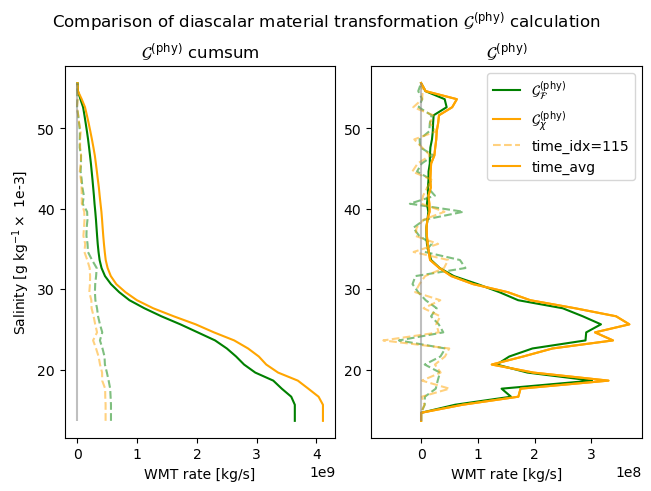

In [119]:
# comparison of G_F_phy and G_chi_phy on salinity coordinates
fig, ax = plt.subplots(nrows=1, ncols=2, constrained_layout=True)

y_values = G_phy_comp_ds.salinity
# plot the time averaged G_F_phy and G_chi_phy cumsums
ax[0].plot(cumsum_G_F_phy_avg, y_values, color='green')
ax[0].plot(cumsum_G_chi_phy_avg, y_values, color='orange')

# plot for a specific time
ax[0].plot(cumsum_G_F_phy_isel, y_values, color='green', alpha=0.5, linestyle='dashed')
ax[0].plot(cumsum_G_chi_phy_isel, y_values, color='orange', alpha=0.5, linestyle='dashed')

# plot the time averaged G_F_phy and G_chi_phy
ax[1].plot(G_F_phy_avg, y_values, color='green',label=r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
ax[1].plot(G_chi_phy_avg, y_values, color='orange',label=r'$\mathcal{G}_\chi^{\text{(phy)}}$')

# plot for a specific time
ax[1].plot(G_F_phy_isel, y_values, color='green', alpha=0.5, linestyle='dashed')
ax[1].plot(G_chi_phy_isel, y_values, color='orange', alpha=0.5, linestyle='dashed',label='time_idx=' + str(time_idx))

# just to get something on the legend
ax[1].plot(G_chi_phy_avg, y_values, color='orange',label='time_avg')

ax[1].legend()

# format
ax[0].vlines(0,ymin=y_values[0], ymax = y_values[-1], color='gray', alpha=0.5)
ax[1].vlines(0,ymin=y_values[0], ymax =y_values[-1], color='gray', alpha=0.5)

fig.suptitle(r'Comparison of diascalar material transformation $\mathcal{G}^{\text{(phy)}}$ calculation')

ax[0].set_xlabel('WMT rate [kg/s]')
ax[1].set_xlabel('WMT rate [kg/s]')

ax[0].set_title(r'$\mathcal{G}^{\text{(phy)}}$ cumsum')
ax[1].set_title(r'$\mathcal{G}^{\text{(phy)}}$')

ax[0].set_ylabel(r'Salinity [g kg$^{-1} \times$ 1e-3]')

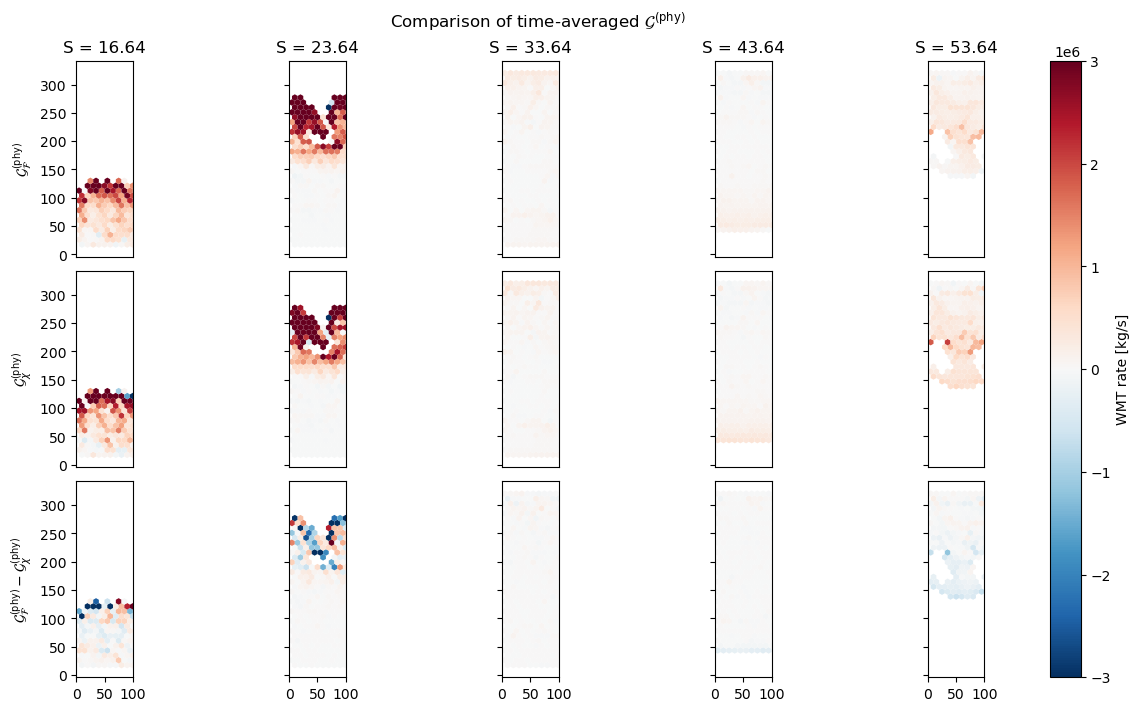

In [109]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds['diff'] = G_phy_comp_ds.G_F_phy_center - G_phy_comp_ds.G_chi_phy

isosurface_idx = np.array([3,10,20,30,40]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, G_phy_comp_ds[row_variables[i]].isel(salinity = isosurface_idx[j]).mean(dim='Time'), 
                          cmap = 'RdBu_r', vmin= -3e6, vmax = 3e6)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison of time-averaged $\mathcal{G}^{\text{(phy)}}$');

## A brief attempt at interpretation
6/29/26

*I really am not convinced that my calculation is correct because I don't understand how $\mathcal{G}^\text{(phy)}$ is positive for all salinity classes. Unless my target coordinates have a $\Delta \tilde\lambda$ that is too large, which I will have to check.*

Regardless, I will attempt some amount of interpretation.

Note that $diff = \mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$. This means that 
- RED:  $ diff > 0 \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} > \mathcal{G}_\chi^{\text{(phy)}} \implies$ convergence of a diffusive flux calculatesm ore physical mixing. 
- BLUE: $ diff < 0 \implies \mathcal{G}_\mathcal{F}^{\text{(phy)}} < \mathcal{G}_\chi^{\text{(phy)}} \implies$ DVD calculates more vertical physical mixing.

*How is `tracerVertMixTendency` actually calculated?*

In the time average, it appears that $\mathcal{G}_\chi^{\text{(phy)}}$ calculates more transformation via mixing than $\mathcal{G}_\mathcal{F}^{\text{(phy)}}$, particularly in the salinity range of 25-30 g/kg x 1e-3. Notably, this salinity range is where the greatest amount of transformation occurs (we all see that hte cumsum graph has the sharpest increase in this range). 
- Our initial salinity conditions have that salinity linearly incraeses away from the base of the channel (cross-channel dist = 0) such that all S is in the range [15,55]
- The equation of state is linear.
- So would we expect linear mixing too?
- In which case, I'm not following why the greatest amount of mixing is occurring in the 20-30 g/kg x 1e-3 range rather than at $\sim$35, which would be the value of linear mixing?
- Maybe temperature has an effect on density and subsequent mixing?

What does the peak of $\mathcal{G}^{\text{(phy)}}$ mean?
- At the peak, most water is mixed into the salinity class defined by $\lambda \ge \tilde\lambda_{maxGphy}$
- more is mixed in than is leaving to become saltier? This would be true for all salinity classes.
- No, I think it means that the amount of mixing into that salinity class is equal to the mixing out of the salinity class s.t. $\partial_\lambda \mathcal{G}^{\text{(phy)}} =0$.
- Need to figure out what a positive slope vs negative slope means, keeping in mind that we calculate $\partial_\lambda \mathcal{G}^{\text{(phy)}}$ using $\lambda_{i} - \lambda_{i+1}$ since we are integrating in the opposite direction.
- What I don't understand is how it's possible if more salty water is leaving than entering how the net $\mathcal{G}^{\text{(phy)}}$ is positive, indicating that the salinity class is still getting saltier?
- I suspect this is something that will be understood when I also understand what a postiive and negative slope means.

Next steps:
- The last 2 cells show that the surface salinity transformation $\mathcal{S}$ and the salinty tendency $\partial_\t S$ both equal 0 (assuming e-7 is close to machine precision or zero??)
- Which means you should be able to calculate the budget, which requires just the $\mathcal{G}$ terms in the budget.
- Since $\mathcal{M}$ is defined only by $\lambda \ge \tilde \lambda$ isosurfaces and not some geographic region, then there is no $\Psi$ term.
- 

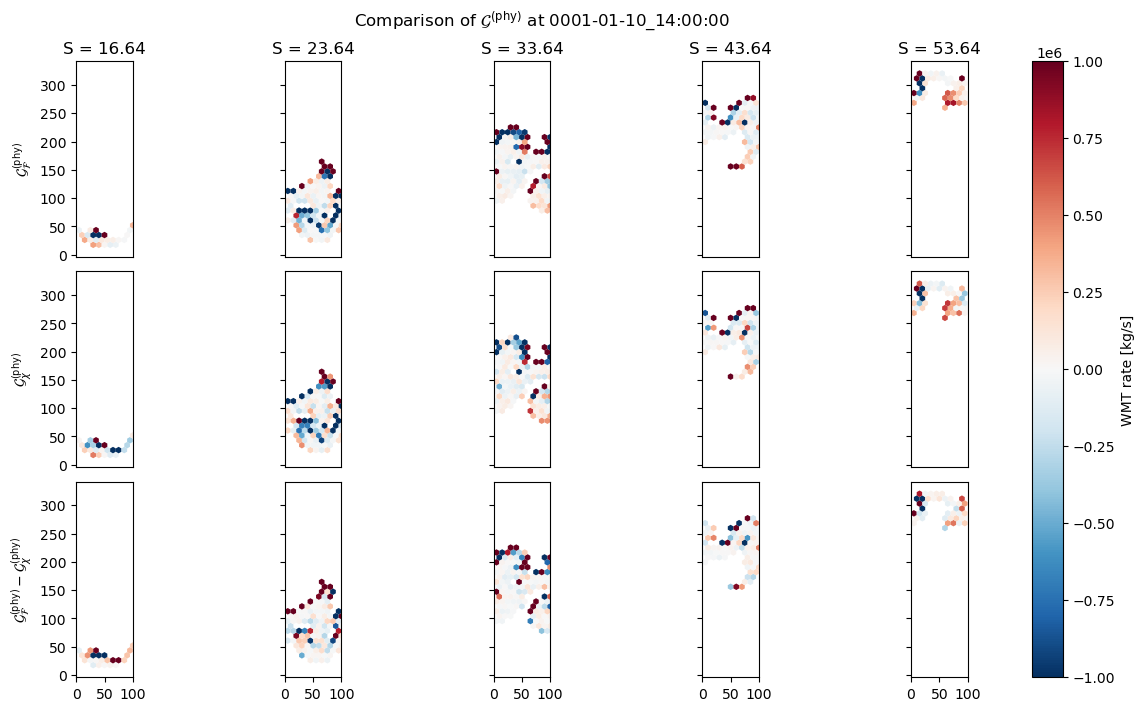

In [114]:
# comparison of G_F_phy and G_chi_phy on salinity surfaces
fig, ax = plt.subplots(nrows=3, ncols=5, constrained_layout=True, figsize=(12,7))

G_phy_comp_ds['diff'] = G_phy_comp_ds.G_F_phy_center - G_phy_comp_ds.G_chi_phy

isosurface_idx = np.array([3,10,20,30,40]) 
row_variables = ['G_F_phy_center' ,'G_chi_phy', 'diff']

for i in range(0,3):
    for j in range(0,5):
        c = mosaic.polypcolor(ax[i,j], descriptor, G_phy_comp_ds[row_variables[i]].isel(salinity = isosurface_idx[j], Time = time_idx), 
                          cmap = 'RdBu_r', vmin= -1e6, vmax = 1e6)

# format
for i in range(0,3):
    for j in range(0,5):
        ax[i,j].set_yticklabels([])
        ax[i,j].set_xticks([])
        ax[i,j].set_aspect(1.0)
        ax[0,j].set_title(f'S = {np.round(G_phy_comp_ds.salinity[isosurface_idx[j]].values,decimals=2)}')
        ax[2,j].set_xticks(np.arange(0,150000,50000))
        ax[2,j].set_xticklabels(np.arange(0,150,50).astype(str))

# y axes
ax[0,0].set_yticks(np.arange(0,350000,50000))
ax[0,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[0,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')

ax[1,0].set_yticks(np.arange(0,350000,50000))
ax[1,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[1,0].set_ylabel(r'$\mathcal{G}_\chi^{\text{(phy)}}$')

ax[2,0].set_yticks(np.arange(0,350000,50000))
ax[2,0].set_yticklabels(np.arange(0,350,50).astype(str))
ax[2,0].set_ylabel(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}} - \mathcal{G}_\chi^{\text{(phy)}}$')

fig.colorbar(c, ax=ax, label = 'WMT rate [kg/s]')
fig.suptitle(r'Comparison of $\mathcal{G}^{\text{(phy)}}$ at ' + str(ds_output.xtime.isel(Time=time_idx).values.item().decode('utf-8')));

In [124]:
ds_output.salinityTend.sum()

<xarray.DataArray 'salinityTend' ()> Size: 4B
array(-1.2665987e-07, dtype=float32)

In [127]:
ds_output.salinitySurfaceFluxTendency.sum()

<xarray.DataArray 'salinitySurfaceFluxTendency' ()> Size: 4B
array(0., dtype=float32)